In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

In [2]:
# --- CONFIGURATION ---
# This is where you adjust the model's sensitivity
CONFIG = {
    'WINDOW_RECENT_DAYS': 7,    # Short-term period (recent trend)
    'WINDOW_HISTORY_DAYS': 14,  # Medium-term period (for comparison)
    'TARGET_WINDOW': 10,        # Prediction window (churn in the next X days)
    'STEP_SIZE': 7,             # We advance by 7 days with each iteration (Data Augmentation)
    'CHURN_EVENT': 'Cancellation Confirmation'
}

In [3]:
def load_and_clean_data(csv_path):
    """
    Loads the data and converts the temporal types.
    """
    print("Loading and cleaning the data...")
    df = pd.read_parquet(csv_path)

    df.drop("ts", axis=1)

    # On supprime les lignes sans userId valide (ex: utilisateurs non loggués)
    df = df[df['userId'].notna()]

    # Converting categorical columns to optimize memory
    categorical_cols = ['gender', 'level', 'page', 'method']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print(f"Data ready: {df.shape[0]} lines, from {df['time'].min()} to {df['time'].max()}")
    return df

In [6]:
#kaggle_challenge/data/churn-prediction-25-26/train.parquet
df=load_and_clean_data("../../../data/churn-prediction-25-26/train.parquet")

Loading and cleaning the data...
Data ready: 17499636 lines, from 2018-10-01 00:00:01 to 2018-11-20 00:00:00


In [7]:
def compute_features_at_anchor(df_window, anchor_date):
    """
    Compute features for all users who are active at a specific date (anchor_date).
    """
    # 1. Time slicing (Past only!)
    # "Recent" period: [Anchor - 7 days, Anchor]
    start_recent = anchor_date - timedelta(days=CONFIG['WINDOW_RECENT_DAYS'])

    # "Historical" period: [Anchor - 28 days, Anchor - 7 days] (we avoid overlap)
    start_history = start_recent - timedelta(days=CONFIG['WINDOW_HISTORY_DAYS'])

    # Global filtering (keep only rows that are needed for feature computation)
    df_past = df_window[(df_window['time'] >= start_history) & (df_window['time'] <= anchor_date)].copy()

    if df_past.empty:
        return None

    # Split into two subsets to compare trends
    mask_recent = df_past['time'] >= start_recent
    df_recent = df_past[mask_recent]
    df_history = df_past[~mask_recent]

    # --- A. STATIC FEATURES & STATE (Last known value) ---
    # Take the last row of each user to get their current state (Paid/Free, etc.)
    last_status = df_past.sort_values('time').groupby('userId').last()

    features = pd.DataFrame(index=df_past['userId'].unique())

    # Simple encoding: Level (1 if paid, 0 if free) - Only if the column exists
    if 'level' in last_status.columns:
        features['is_paid'] = (last_status['level'] == 'paid').astype(int)

    # Gender (1 if F, 0 if M for example)
    if 'gender' in last_status.columns:
        features['gender_F'] = (last_status['gender'] == 'F').astype(int)

    # Recency: Days since the very last action
    last_action_date = df_past.groupby('userId')['time'].max()
    features['days_since_last_action'] = (anchor_date - last_action_date).dt.total_seconds() / (3600 * 24)

    # --- B. ACTIVITY FEATURES (Counts) ---
    # Helper function to avoid repetition
    def get_counts(df_sub, prefix):
        counts = df_sub.groupby('userId').agg({
            'page': 'count',                 # Total actions
            'song': 'count',                 # Total songs
            'sessionId': 'nunique'           # Total sessions
        }).rename(columns={
            'page': f'{prefix}_actions',
            'song': f'{prefix}_songs',
            'sessionId': f'{prefix}_sessions'
        })

        # Specific events (Thumbs Up, Thumbs Down, Errors, Add to Playlist)
        # Use crosstab or conditional sums
        events = df_sub[df_sub['page'].isin(['Thumbs Up', 'Thumbs Down', 'Error', 'Add to Playlist'])]
        if not events.empty:
            event_counts = pd.crosstab(events['userId'], events['page']).add_prefix(f'{prefix}_')
            counts = counts.merge(event_counts, on='userId', how='left')

        return counts

    feats_recent = get_counts(df_recent, 'recent')
    feats_history = get_counts(df_history, 'history')

    # Merge
    features = features.join(feats_recent, how='left').join(feats_history, how='left').fillna(0)

    # --- C. TREND FEATURES (EVOLUTION) ---
    # This is key for churn detection: is activity decreasing?
    # We compute daily averages to compare periods of different lengths

    avg_songs_recent = features['recent_songs'] / CONFIG['WINDOW_RECENT_DAYS']
    avg_songs_history = features['history_songs'] / CONFIG['WINDOW_HISTORY_DAYS']

    # Trend ratio: (Recent + epsilon) / (History + epsilon)
    # If < 1: activity is going down
    epsilon = 0.1  # To avoid division by zero
    features['trend_song_consumption'] = (avg_songs_recent + epsilon) / (avg_songs_history + epsilon)

    # Error ratio (is the user facing more bugs recently?)
    if 'recent_Error' in features.columns and 'history_Error' in features.columns:
        features['trend_error_rate'] = (features['recent_Error'] + epsilon) / (features['history_Error'] + epsilon)

    # Add the anchor date for tracking
    features['anchor_date'] = anchor_date

    return features


In [8]:
def run_feature_engineering_pipeline(df_logs):
    """
    Runs the sliding window loop and generates the full Train/Test dataset.
    """
    print("Starting Sliding Window pipeline...")

    min_date = df_logs['time'].min()
    max_date = df_logs['time'].max()

    # We start only when we have enough history
    start_anchor = min_date + timedelta(days=CONFIG['WINDOW_HISTORY_DAYS'] + CONFIG['WINDOW_RECENT_DAYS'])
    # We stop before the very end so we still have future data to build the target
    end_anchor = max_date - timedelta(days=CONFIG['TARGET_WINDOW'])

    current_date = start_anchor
    final_datasets = []

    while current_date <= end_anchor:
        print(f"Processing window for anchor date: {current_date.date()}")

        # 1. Generate features (X) for this anchor date
        # Use a wide view on the data to avoid unnecessary copies
        window_start = current_date - timedelta(days=CONFIG['WINDOW_HISTORY_DAYS'] +
                                                     CONFIG['WINDOW_RECENT_DAYS'] + 1)
        df_view = df_logs[(df_logs['time'] >= window_start) & (df_logs['time'] <= max_date)]

        features = compute_features_at_anchor(df_view, current_date)

        if features is None or features.empty:
            current_date += timedelta(days=CONFIG['STEP_SIZE'])
            continue

        # 2. Generate the target (Y) - Future
        # Look into the future [Anchor, Anchor + TARGET_WINDOW days]
        future_mask = (df_view['time'] > current_date) & \
                      (df_view['time'] <= current_date + timedelta(days=CONFIG['TARGET_WINDOW']))

        future_data = df_view[future_mask]

        # Identify churners
        churn_users = future_data[future_data['page'] == CONFIG['CHURN_EVENT']]['userId'].unique()

        features['target_churn'] = 0
        features.loc[features.index.isin(churn_users), 'target_churn'] = 1

        final_datasets.append(features)

        # Move the sliding window forward
        current_date += timedelta(days=CONFIG['STEP_SIZE'])

    # Final concatenation
    if not final_datasets:
        print("Warning: No valid window generated (dataset too short?)")
        return pd.DataFrame()

    full_dataset = pd.concat(final_datasets).reset_index().rename(columns={'index': 'userId'})

    print(f"Pipeline finished. Dataset generated with shape: {full_dataset.shape}")
    return full_dataset


In [9]:
df_train_ready = run_feature_engineering_pipeline(df)

Starting Sliding Window pipeline...
Processing window for anchor date: 2018-10-22
Processing window for anchor date: 2018-10-29
Processing window for anchor date: 2018-11-05
Pipeline finished. Dataset generated with shape: (50548, 22)


In [10]:
print(df_train_ready['target_churn'].value_counts())
df_train_ready.head()

target_churn
0    48185
1     2363
Name: count, dtype: int64


,userId,is_paid,gender_F,days_since_last_action,recent_actions,recent_songs,recent_sessions,recent_Add to Playlist,recent_Error,recent_Thumbs Down,...,history_songs,history_sessions,history_Add to Playlist,history_Error,history_Thumbs Down,history_Thumbs Up,trend_song_consumption,trend_error_rate,anchor_date,target_churn
0,1749042,1,0,0.946956,94.0,70.0,2.0,2.0,0.0,0.0,...,954.0,7.0,31.0,0.0,9.0,46.0,0.148001,1.000000,2018-10-22 00:00:01,0
1,1563081,1,1,2.354271,102.0,86.0,1.0,1.0,0.0,3.0,...,25.0,1.0,0.0,0.0,0.0,1.0,6.568182,1.000000,2018-10-22 00:00:01,0
2,1697168,0,1,2.014664,98.0,74.0,4.0,3.0,0.0,0.0,...,344.0,10.0,8.0,1.0,5.0,16.0,0.432542,0.090909,2018-10-22 00:00:01,0
3,1222580,0,0,2.366354,20.0,12.0,3.0,0.0,0.0,2.0,...,1424.0,13.0,40.0,2.0,15.0,68.0,0.017820,0.047619,2018-10-22 00:00:01,1
4,1714398,1,1,0.080394,542.0,452.0,2.0,21.0,0.0,5.0,...,461.0,5.0,13.0,1.0,5.0,24.0,1.958045,0.090909,2018-10-22 00:00:01,0


In [11]:
df_train_ready[df_train_ready["userId"]=="1697168"]

,userId,is_paid,gender_F,days_since_last_action,recent_actions,recent_songs,recent_sessions,recent_Add to Playlist,recent_Error,recent_Thumbs Down,...,history_songs,history_sessions,history_Add to Playlist,history_Error,history_Thumbs Down,history_Thumbs Up,trend_song_consumption,trend_error_rate,anchor_date,target_churn
2,1697168,0,1,2.014664,98.0,74.0,4.0,3.0,0.0,0.0,...,344.0,10.0,8.0,1.0,5.0,16.0,0.432542,0.090909,2018-10-22 00:00:01,0
17502,1697168,0,1,0.570116,293.0,221.0,6.0,3.0,0.0,2.0,...,171.0,9.0,5.0,1.0,2.0,11.0,2.571926,0.090909,2018-10-29 00:00:01,0
34335,1697168,1,1,0.015150,207.0,160.0,5.0,6.0,0.0,1.0,...,295.0,10.0,6.0,0.0,2.0,21.0,1.084345,1.000000,2018-11-05 00:00:01,0


In [12]:
def train_eval_model(df_train):
    """
    Train an XGBoost model with GroupKFold cross-validation
    to avoid leakage between sliding windows of the same user.
    """
    print("--- Starting model training ---")

    # 1. Feature preparation
    # Exclude technical columns that are not input features
    ignore_cols = ['userId', 'target_churn', 'anchor_date', 'ts_date']
    features = [c for c in df_train.columns if c not in ignore_cols]

    X = df_train[features]
    y = df_train['target_churn']
    groups = df_train['userId']  # Crucial for GroupKFold to group by user

    print(f"Detected features ({len(features)}): {features}")

    # 2. Model definition
    clf = xgb.XGBClassifier(
        n_estimators=500,        # Number of trees
        learning_rate=0.03,      # Learning rate (smaller = more precise but slower)
        max_depth=5,             # Tree depth
        subsample=0.8,           # Row subsampling to reduce overfitting
        colsample_bytree=0.8,    # Column subsampling to reduce overfitting
        scale_pos_weight=10,     # Handle class imbalance (churners are rare)
        eval_metric='auc',
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50
    )

    # 3. Cross-validation (5 folds)
    gkf = GroupKFold(n_splits=5)
    fold_scores = []
    feature_importance_df = pd.DataFrame(index=features)
    feature_importance_df['gain'] = 0

    for i, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        # Fold score
        preds = clf.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, preds)
        fold_scores.append(score)

        # Feature importance
        feature_importance_df['gain'] += clf.feature_importances_
        print(f"Fold {i+1} AUC: {score:.4f}")

    print(f"\n>>> FINAL MEAN SCORE (AUC): {np.mean(fold_scores):.4f} <<<")

    # 4. Display most important features
    feature_importance_df['gain'] /= 5
    feature_importance_df = feature_importance_df.sort_values('gain', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='gain', y=feature_importance_df.index[:15], data=feature_importance_df.iloc[:15])
    plt.title('Top 15 Most Important Features')
    plt.tight_layout()
    plt.show()  # If you are in a notebook; otherwise you can use plt.savefig('importance.png')

    # Final training on the FULL dataset for deployment / submission
    print("Retraining final model on the full dataset...")
    clf.set_params(early_stopping_rounds=None)
    clf.fit(X, y, verbose=False)

    return clf, features


--- Starting model training ---
Detected features (19): ['is_paid', 'gender_F', 'days_since_last_action', 'recent_actions', 'recent_songs', 'recent_sessions', 'recent_Add to Playlist', 'recent_Error', 'recent_Thumbs Down', 'recent_Thumbs Up', 'history_actions', 'history_songs', 'history_sessions', 'history_Add to Playlist', 'history_Error', 'history_Thumbs Down', 'history_Thumbs Up', 'trend_song_consumption', 'trend_error_rate']
Fold 1 AUC: 0.7091
Fold 2 AUC: 0.7301
Fold 3 AUC: 0.7198
Fold 4 AUC: 0.7083
Fold 5 AUC: 0.7307

>>> FINAL MEAN SCORE (AUC): 0.7196 <<<


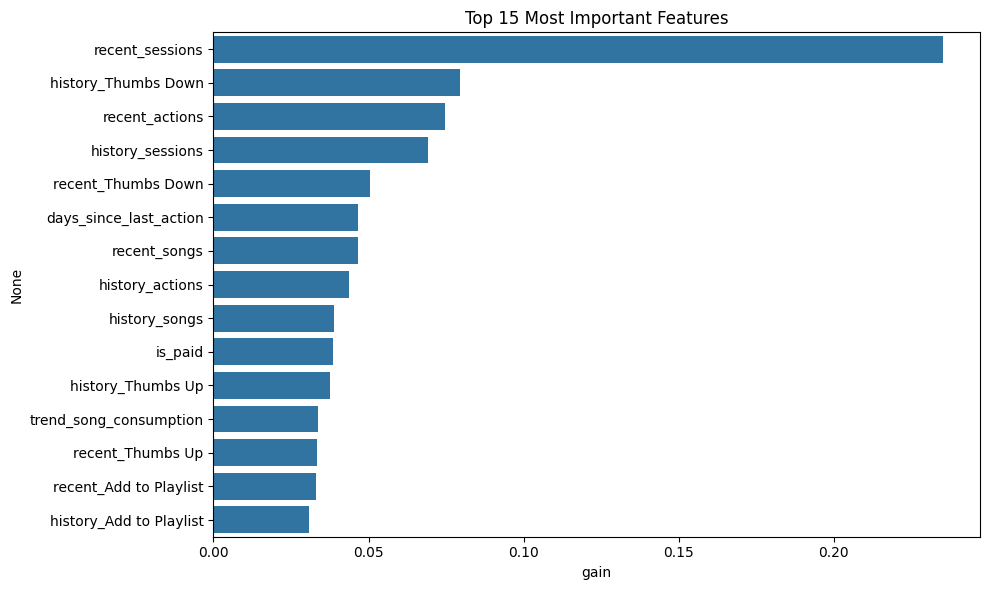

Retraining final model on the full dataset...


In [13]:
model, features=train_eval_model(df_train_ready)

In [14]:
def generate_kaggle_submission(
    model,
    df_logs_full,
    feature_cols,
    all_test_user_ids,
    output_file='submission.csv',
    seuil=0.5
):
    """
    Generate a BINARY Kaggle submission, with robust handling of ID types
    and users without activity in the final window.
    """
    print("\n--- Generating ROBUST submission file (Binary Mode) ---")

    # 1. Reference date (anchor)
    last_date = df_logs_full['time'].max()
    print(f"Anchor date: {last_date}")

    # 2. Compute features for users active around the anchor date
    X_test_active = compute_features_at_anchor(df_logs_full, last_date)

    if X_test_active is None:
        X_test_active = pd.DataFrame()
        print("Warning: No active users in the last window!")

    # 3. Predictions for active users
    if not X_test_active.empty:
        # Ensure all expected feature columns are present
        for col in feature_cols:
            if col not in X_test_active.columns:
                X_test_active[col] = 0

        # Keep the same column order as in training
        X_test_active = X_test_active[feature_cols]

        active_probs = model.predict_proba(X_test_active)[:, 1]

        df_preds = pd.DataFrame({
            'userId': X_test_active.index,
            'prediction': active_probs
        })
    else:
        df_preds = pd.DataFrame(columns=['userId', 'prediction'])

    # 4. Merge with the full test user list
    # Start from all test user IDs provided (e.g., from sample_submission or test.csv)
    final_submission = pd.DataFrame({'userId': all_test_user_ids})

    # --- IMPORTANT: Harmonize ID types so the merge works correctly ---
    final_submission['userId'] = final_submission['userId'].astype(str)
    df_preds['userId'] = df_preds['userId'].astype(str)

    # Remove potential duplicates to avoid exploding the number of rows
    final_submission = final_submission.drop_duplicates(subset=['userId'])
    df_preds = df_preds.drop_duplicates(subset=['userId'])

    # Left join: keep all test users, attach predictions where available
    final_submission = final_submission.merge(df_preds, on='userId', how='left')

    # 5. Handle missing predictions (users inactive in the last window)
    avg_proba = final_submission['prediction'].mean()
    if pd.isna(avg_proba):
        avg_proba = 0.5  # fallback if no predictions at all

    missing_count = final_submission['prediction'].isna().sum()
    print(
        f"Inactive users: {missing_count} "
        f"(filled with mean probability: {avg_proba:.4f})"
    )

    final_submission['prediction'] = final_submission['prediction'].fillna(avg_proba)

    # 6. Apply threshold to get binary churn label
    final_submission['is_churn'] = (final_submission['prediction'] >= seuil).astype(int)

    # 7. Save submission file
    output_df = final_submission[['userId', 'is_churn']]
    output_df.columns = ['id', 'target']

    output_df.to_csv(output_file, index=False)
    print(f"Saved: {output_file} ({len(output_df)} rows)")

    return output_df


In [17]:
sample = pd.read_csv('../../../data/churn-prediction-25-26/example_submission.csv')
all_users_list = sample['id'].unique()
all_users_list

array([1128274, 1782451, 1611542, ..., 1724758, 1879724, 1749215])

In [19]:
test_set=pd.read_parquet("../../../data/churn-prediction-25-26/test.parquet")

In [20]:
submit_df = generate_kaggle_submission(model, test_set, features, all_users_list, seuil=0.4)


--- Generating ROBUST submission file (Binary Mode) ---
Anchor date: 2018-11-20 00:00:00
Inactive users: 119 (filled with mean probability: 0.3049)
Saved: submission.csv (2904 rows)
